### Photodiode Comparison + Cross-calibration

Run through all available filters, and record readings first with the Ge Photodiode, and then with the Si Photodiode

In [4]:
import numpy as numpy
import time
import os
import matplotlib.pyplot as plt
# Lab Hardware Control
import Pyro5.api as pyro
import json

# Connect to the lab server
labserver = pyro.Proxy("PYRO:LabServer@localhost:50000")

In [19]:
filter = 1350
labserver.select_bandpass(filter)
labserver.shutter("open")

In [ ]:
# take a test image
exptime = 10
labserver.set_exposure(exptime)

# take a test image
cam.capture_frames(25, stack = False, headers = header, show_progress = False)


In [ ]:
# All the available filters
# get the available filters from the lab server
wheels = labserver.list_wheels()

# for each wheel, get the available filters
filters = [296.7, 400, 500, 550, 600, 640, 700, 800, 900, 1000, 1064,
           1050, 1150, 1250, 1350, 
           #1450, 1560, 1650,
           ]
saturation = 14255 # half saturation -> 7127
bias_level = 2552
halfwell_exptime = {
    296.7: 60.0,
    400 : 0.5,
    500 : 0.75,
    600 : 0.5,
    640 : 0.6,
    700 : 0.6,
    800 : 0.6,
    900 : 0.4,
    1050 : 1.5,
    1064 : 1.5,
    1150 : 2.5,
    1250 : 10.0,
    1350 : 15.0,

    }

print(wheels)

print(4*15)

['fw1', 'fw2', 'fw3', 'fw4']
60


In [ ]:
import json
import os
# step through each filter, then get a dark (shutter closed) reading
# and a light (shutter open) reading from the photodiode

n_readings_current = 100
dt_readings_current = 0.1
settle_time_s = 30.0

ge_results = {}
si_results = {}
filters = filters[:2]  # limit to the first two filters for testing
for filter in filters:
    # select the filter
    labserver.select_bandpass(filter)
    
    

    # get a dark reading
    print(f"Running filter: {filter} nm")
    print("\tClosing shutter for dark reading...")
    labserver.shutter("close")

    # wait for the system to settle
    print(f"\tWaiting for {settle_time_s} seconds for the system to settle...")
    time.sleep(settle_time_s)

    # reinitialize the ammeter connection
    print("\tReading ge photodiode current...")
    dark_reading_ge = labserver.read_multisample_current("ge",
        n_readings_current,
        dt = dt_readings_current,
        return_arr=True,
        )
    print("\tReading si photodiode current...")
    dark_reading_si = labserver.read_multisample_current("si",
        n_readings_current, 
        dt = dt_readings_current,
        return_arr=True,
        )
    
    
    # get a light reading
    print("\tOpening shutter for light reading...")
    labserver.shutter("open")
    # wait for the system to settle
    print(f"\tWaiting for {settle_time_s} seconds for the system to settle...")
    time.sleep(settle_time_s)
    print("\tReading ge photodiode current...")
    light_reading_ge = labserver.read_multisample_current("ge",
        n_readings_current,
        dt = dt_readings_current,
        return_arr=True)
    print("\tReading si photodiode current...")
    light_reading_si = labserver.read_multisample_current("si",
        n_readings_current,
        dt = dt_readings_current,
        return_arr=True)
    print("\tupdating dictionaries")
    delta_ge = light_reading_ge['mean'] - dark_reading_ge['mean']
    delta_si = light_reading_si['mean'] - dark_reading_si['mean']
    
    print(f"\tFilter: {filter} nm, Ge: {delta_ge:.2e} A, Si: {delta_si:.2e} A")

    ge_results[filter] = {
        "dark": dark_reading_ge,
        "light": light_reading_ge,
    }

    si_results[filter] = {
        "dark": dark_reading_si,
        "light": light_reading_si,
    }

results = {
    "ge": ge_results,
    "si": si_results,
}

# save the results to a file
outdir = os.path.join(os.path.expanduser("~"), "data", "photodiode_cross_calibration")
if not os.path.exists(outdir):
    os.makedirs(outdir)
outfile = os.path.join(outdir, "photodiode_measurements_all_filters.json")
# write the file and overwrite if it exists
print(f"Saving results to {outfile}")
with open(outfile, "w") as f:
    json.dump(ge_results, f, indent=4)

Running filter: 296.7 nm
Closing shutter for dark reading...
Waiting for 60.0 seconds for the system to settle...
Reading ge photodiode current...
Reading si photodiode current...
Opening shutter for light reading...
Waiting for 60.0 seconds for the system to settle...
Reading ge photodiode current...
Reading si photodiode current...
updating dictionaries
Filter: 296.7 nm, Ge: -3.56e-11 A, Si: 1.60e-12 A
Running filter: 400 nm
Closing shutter for dark reading...
Waiting for 60.0 seconds for the system to settle...
Reading ge photodiode current...
Reading si photodiode current...
Opening shutter for light reading...
Waiting for 60.0 seconds for the system to settle...
Reading ge photodiode current...
Reading si photodiode current...
updating dictionaries
Filter: 400 nm, Ge: 5.26e-09 A, Si: 7.67e-11 A


dict_items([('ge', {296.7: {'dark': {'n_samples': 100, 'mean': 6.3069389999999986e-09, 'median': 6.318563e-09, 'std': 2.8796482948506054e-10, 'current': [6.513039e-09, 6.823843e-09, 6.218311e-09, 5.939151e-09, 6.345436e-09, 6.922383e-09, 6.269286e-09, 5.7824e-09, 6.464994e-09, 6.290113e-09, 5.920256e-09, 6.451579e-09, 6.044784e-09, 6.461926e-09, 6.196482e-09, 6.482278e-09, 6.590371e-09, 6.299915e-09, 6.720438e-09, 6.49529e-09, 6.921628e-09, 6.776439e-09, 6.21961e-09, 6.174357e-09, 6.505577e-09, 6.595101e-09, 6.590014e-09, 6.405363e-09, 6.653169e-09, 6.457446e-09, 6.103507e-09, 6.234794e-09, 6.648429e-09, 6.487877e-09, 6.442239e-09, 6.125532e-09, 6.275194e-09, 6.547397e-09, 6.463031e-09, 6.334743e-09, 6.130993e-09, 7.048056e-09, 6.281052e-09, 6.338167e-09, 6.319874e-09, 6.424983e-09, 6.036656e-09, 6.326655e-09, 6.027891e-09, 6.119402e-09, 6.034483e-09, 6.018444e-09, 6.375201e-09, 6.401903e-09, 6.070573e-09, 6.578595e-09, 6.752387e-09, 6.459802e-09, 6.282649e-09, 6.446479e-09, 6.656871e-

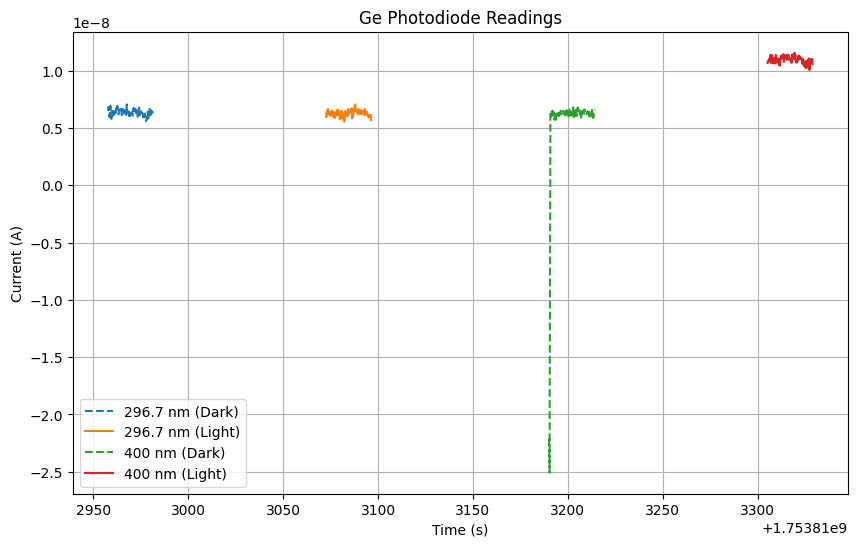

readings: {'dark': {'n_samples': 100, 'mean': 2.0069279242000003e-12, 'median': 2.080114e-12, 'std': 1.2981760076885922e-12, 'current': [2.938094e-12, 1.172396e-12, 2.263079e-12, 2.039258e-12, 1.271871e-12, 2.653877e-12, 1.261213e-12, 2.241762e-12, 2.54019e-12, 1.417533e-12, 2.845724e-12, 9.30811e-13, 2.0286e-12, 2.629008e-12, 1.563194e-13, 3.382183e-12, 1.424638e-12, 1.637801e-12, 2.625455e-12, 9.30811e-13, 3.385736e-12, 1.946887e-12, 2.085443e-12, 3.350209e-12, 3.019807e-13, 3.275602e-12, 1.573852e-12, 9.30811e-13, 3.719691e-12, -9.592327e-14, 3.129941e-12, 1.712408e-12, 8.56204e-13, 3.350209e-12, 3.161915e-13, 2.319922e-12, 2.469136e-12, 1.769251e-12, 3.019807e-12, 1.360689e-12, 2.529532e-12, 2.302158e-12, 1.570299e-12, 3.709033e-12, 9.841017e-13, 1.95044e-12, 3.414158e-12, 6.146195e-13, 3.801404e-12, 1.396216e-12, 2.074785e-12, 3.108624e-12, -1.847411e-13, 3.833378e-12, 1.609379e-12, 2.085443e-12, 2.668088e-12, 8.31335e-13, 3.165468e-12, 7.958079e-13, 2.170708e-12, 3.19389e-12, 1.4

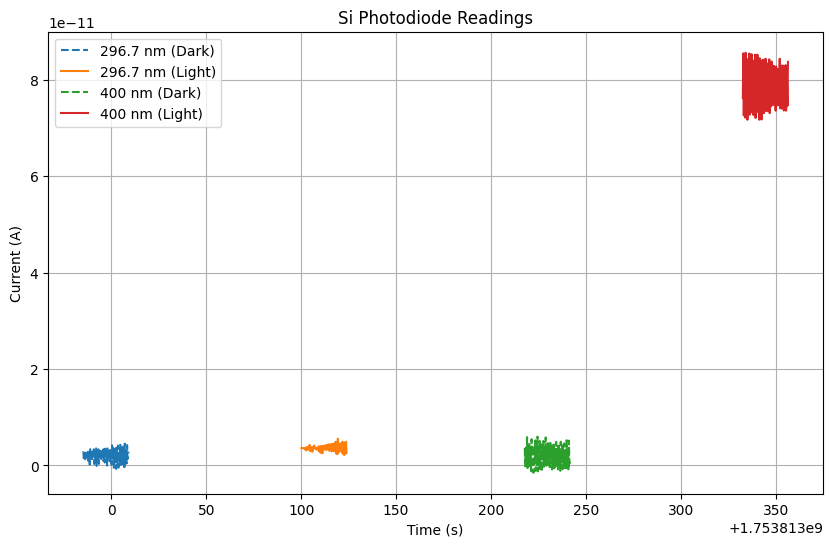

In [4]:
print(results.items())

for pd, filters in results.items():
    plt.figure(figsize=(10, 6))


    for filter in filters:
        readings = results[pd][filter]
        print(f"readings: {readings}")
        plt.plot(readings['dark']['time'], readings['dark']['current'], label=f"{filter} nm (Dark)", linestyle='--')
        # plot the mean dark in a line with the same color
        plt.plot(readings['light']['time'], readings['light']['current'], label=f"{filter} nm (Light)")
    
    plt.title(f"{pd.capitalize()} Photodiode Readings")
    plt.xlabel("Time (s)")
    plt.ylabel("Current (A)")
    plt.legend()
    plt.grid()
    plt.show()